# 03 — Data Splits
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook creates all train/val/test splits needed for robust evaluation:

1. **Random split** (80/10/10) — stratified by `label_binary`
2. **Source-held-out split** — one full source dataset held out as test
3. **Script-held-out split** — Romanized (Banglish) text held out as test
4. **External test** — reserved dataset never seen during any training

All splits are saved as CSV files and also as a single JSON manifest for easy loading.

**Prerequisites:** Run `02_preprocessing_and_eda.ipynb` first so that `data/processed/benchmark_cleaned.csv` exists.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

print(f"Seed: {SEED}")

Seed: 42


In [2]:
# ── Load cleaned data ──────────────────────────────────────────────────────
DATA_PATH = "../data/processed/benchmark_cleaned.csv"
SPLIT_DIR = "../data/splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")

# Ensure index is clean
df = df.reset_index(drop=True)
df["idx"] = df.index  # keep original index for split tracking

Loaded: ../data/processed/benchmark_cleaned.csv
Shape : (135575, 7)
Columns: ['text', 'label_binary', 'label_type', 'source', 'script', 'original_file', 'text_clean']


## 1 — Random Stratified Split (80/10/10)

Standard train/val/test split, stratified by the binary label to preserve class balance.

In [3]:
# ── Determine stratify column ──────────────────────────────────────────────
LABEL_COL = "label_binary"  # adjust if needed

if LABEL_COL not in df.columns:
    print(f"⚠ '{LABEL_COL}' not found. Using no stratification.")
    strat = None
else:
    strat = df[LABEL_COL]
    print(f"Stratifying on '{LABEL_COL}': {dict(strat.value_counts())}")

# 80% train, 10% val, 10% test
train_idx, temp_idx = train_test_split(
    df.index, test_size=0.20, random_state=SEED,
    stratify=strat
)
strat_temp = strat.iloc[temp_idx] if strat is not None else None
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED,
    stratify=strat_temp
)

df_train = df.loc[train_idx].reset_index(drop=True)
df_val   = df.loc[val_idx].reset_index(drop=True)
df_test  = df.loc[test_idx].reset_index(drop=True)

print(f"\n── Random Split ──")
print(f"  Train : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(df_test):,}  ({len(df_test)/len(df)*100:.1f}%)")

if LABEL_COL in df.columns:
    for name, split_df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
        vc = split_df[LABEL_COL].value_counts(normalize=True) * 100
        print(f"  {name} class balance: {dict(vc.round(1))}")

# Save
df_train.to_csv(f"{SPLIT_DIR}/random_train.csv", index=False)
df_val.to_csv(f"{SPLIT_DIR}/random_val.csv", index=False)
df_test.to_csv(f"{SPLIT_DIR}/random_test.csv", index=False)
print(f"\n✅ Saved to {SPLIT_DIR}/random_*.csv")

Stratifying on 'label_binary': {0: np.int64(75545), 1: np.int64(60030)}

── Random Split ──
  Train : 108,460 (80.0%)
  Val   : 13,557  (10.0%)
  Test  : 13,558  (10.0%)
  Train class balance: {0: np.float64(55.7), 1: np.float64(44.3)}
  Val class balance: {0: np.float64(55.7), 1: np.float64(44.3)}
  Test class balance: {0: np.float64(55.7), 1: np.float64(44.3)}

✅ Saved to ../data/splits/random_*.csv


## 2 — 5-Fold Cross-Validation Indices

For robust training with seed averaging, we also create 5-fold CV indices.

In [4]:
N_FOLDS = 5

if LABEL_COL in df.columns:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_iter = skf.split(df, df[LABEL_COL])
else:
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_iter = kf.split(df)

fold_indices = {}
print(f"── {N_FOLDS}-Fold CV ──")
for fold, (tr_idx, te_idx) in enumerate(fold_iter):
    fold_indices[fold] = {"train": tr_idx.tolist(), "test": te_idx.tolist()}
    print(f"  Fold {fold}: train={len(tr_idx):,}  test={len(te_idx):,}")

# Save fold indices as JSON
with open(f"{SPLIT_DIR}/cv_folds.json", "w") as f:
    json.dump(fold_indices, f)
print(f"\n✅ Saved: {SPLIT_DIR}/cv_folds.json")

── 5-Fold CV ──
  Fold 0: train=108,460  test=27,115
  Fold 1: train=108,460  test=27,115
  Fold 2: train=108,460  test=27,115
  Fold 3: train=108,460  test=27,115
  Fold 4: train=108,460  test=27,115

✅ Saved: ../data/splits/cv_folds.json


## 3 — Source-Held-Out Split

For evaluating cross-domain robustness, we hold out one complete source dataset as the test set and train on the rest. This tests whether the model generalizes across data sources.

In [5]:
if "source" in df.columns:
    sources = df["source"].unique()
    print(f"Available sources: {list(sources)}")
    print(f"\n── Samples per source ──")
    for s in sources:
        n = (df["source"] == s).sum()
        print(f"  {s}: {n:,}")
    
    # Hold out each source and save
    # For the paper, we'll pick the best one(s) to report
    for holdout_source in sources:
        mask_test = df["source"] == holdout_source
        df_src_test = df[mask_test].reset_index(drop=True)
        df_src_rest = df[~mask_test].reset_index(drop=True)
        
        # Split rest into train/val (90/10)
        strat_rest = df_src_rest[LABEL_COL] if LABEL_COL in df_src_rest.columns else None
        src_train_idx, src_val_idx = train_test_split(
            df_src_rest.index, test_size=0.10, random_state=SEED,
            stratify=strat_rest
        )
        df_src_train = df_src_rest.loc[src_train_idx].reset_index(drop=True)
        df_src_val = df_src_rest.loc[src_val_idx].reset_index(drop=True)
        
        safe_name = holdout_source.replace(" ", "_").replace("/", "_")
        df_src_train.to_csv(f"{SPLIT_DIR}/source_holdout_{safe_name}_train.csv", index=False)
        df_src_val.to_csv(f"{SPLIT_DIR}/source_holdout_{safe_name}_val.csv", index=False)
        df_src_test.to_csv(f"{SPLIT_DIR}/source_holdout_{safe_name}_test.csv", index=False)
    
    print(f"\n✅ Saved source-held-out splits for {len(sources)} sources.")
else:
    print("⚠ 'source' column not found — skipping source-held-out splits.")

Available sources: ['banth', 'bd_shs', 'facebook_44001', 'multilabel_12557']

── Samples per source ──
  banth: 73,999
  bd_shs: 5,029
  facebook_44001: 44,001
  multilabel_12557: 12,546

✅ Saved source-held-out splits for 4 sources.


## 4 — Script-Held-Out Split

Hold out Romanized (Banglish) text as the test set. This tests whether the model handles script transfer.

In [6]:
if "script" in df.columns:
    scripts = df["script"].unique()
    print(f"Available scripts: {list(scripts)}")
    print(f"\n── Samples per script ──")
    for s in scripts:
        n = (df["script"] == s).sum()
        print(f"  {s}: {n:,}")
    
    # Hold out 'romanized' or 'banglish' or 'mixed' — whichever exists
    holdout_candidates = ["romanized", "banglish", "roman", "mixed"]
    holdout_script = None
    for cand in holdout_candidates:
        matches = [s for s in scripts if cand.lower() in str(s).lower()]
        if matches:
            holdout_script = matches[0]
            break
    
    if holdout_script is None:
        # Default: hold out the minority script
        holdout_script = df["script"].value_counts().idxmin()
        print(f"No romanized/banglish found. Holding out minority script: '{holdout_script}'")
    
    print(f"\n→ Holding out script: '{holdout_script}'")
    
    mask_test = df["script"] == holdout_script
    df_script_test = df[mask_test].reset_index(drop=True)
    df_script_rest = df[~mask_test].reset_index(drop=True)
    
    strat_rest = df_script_rest[LABEL_COL] if LABEL_COL in df_script_rest.columns else None
    scr_train_idx, scr_val_idx = train_test_split(
        df_script_rest.index, test_size=0.10, random_state=SEED,
        stratify=strat_rest
    )
    df_script_train = df_script_rest.loc[scr_train_idx].reset_index(drop=True)
    df_script_val = df_script_rest.loc[scr_val_idx].reset_index(drop=True)
    
    df_script_train.to_csv(f"{SPLIT_DIR}/script_holdout_train.csv", index=False)
    df_script_val.to_csv(f"{SPLIT_DIR}/script_holdout_val.csv", index=False)
    df_script_test.to_csv(f"{SPLIT_DIR}/script_holdout_test.csv", index=False)
    
    print(f"  Train : {len(df_script_train):,}")
    print(f"  Val   : {len(df_script_val):,}")
    print(f"  Test  : {len(df_script_test):,} (all '{holdout_script}')")
    print(f"\n✅ Saved script-held-out splits.")
else:
    print("⚠ 'script' column not found — skipping script-held-out split.")
    print("  If you have Romanized text mixed in, consider adding a 'script' column.")

Available scripts: ['romanized', 'bangla']

── Samples per script ──
  romanized: 73,999
  bangla: 61,576

→ Holding out script: 'romanized'
  Train : 55,418
  Val   : 6,158
  Test  : 73,999 (all 'romanized')

✅ Saved script-held-out splits.


## 5 — Split Summary & Manifest

In [7]:
# ── Create a manifest of all splits ────────────────────────────────────────
manifest = {
    "seed": SEED,
    "total_samples": len(df),
    "splits": {}
}

# List all split files
for fname in sorted(os.listdir(SPLIT_DIR)):
    if fname.endswith(".csv"):
        fpath = os.path.join(SPLIT_DIR, fname)
        n_rows = sum(1 for _ in open(fpath)) - 1  # minus header
        manifest["splits"][fname] = n_rows

with open(f"{SPLIT_DIR}/manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("── All Splits ──")
for fname, n in manifest["splits"].items():
    print(f"  {fname:<50s} {n:>7,} samples")

print(f"\n✅ Manifest saved: {SPLIT_DIR}/manifest.json")

── All Splits ──
  random_test.csv                                     14,248 samples
  random_train.csv                                   114,002 samples
  random_val.csv                                      14,333 samples
  script_holdout_test.csv                             80,372 samples
  script_holdout_train.csv                            55,990 samples
  script_holdout_val.csv                               6,221 samples
  source_holdout_banth_test.csv                       80,372 samples
  source_holdout_banth_train.csv                      55,990 samples
  source_holdout_banth_val.csv                         6,221 samples
  source_holdout_bd_shs_test.csv                       5,032 samples
  source_holdout_bd_shs_train.csv                    123,722 samples
  source_holdout_bd_shs_val.csv                       13,829 samples
  source_holdout_facebook_44001_test.csv              44,114 samples
  source_holdout_facebook_44001_train.csv             88,545 samples
  source_holdout_

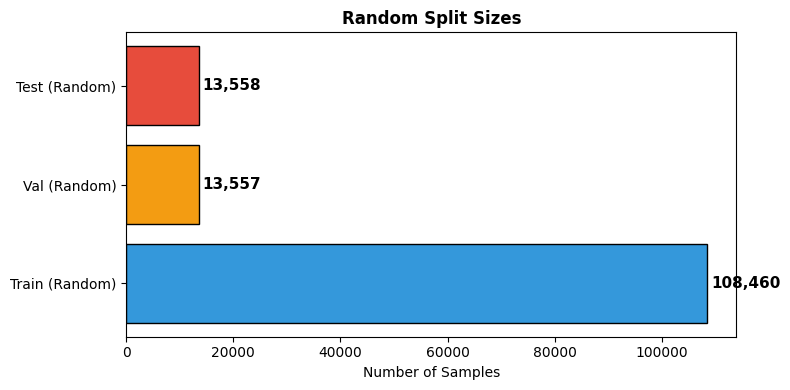

In [8]:
# ── Visual summary ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

split_names = ["Train (Random)", "Val (Random)", "Test (Random)"]
split_sizes = [len(df_train), len(df_val), len(df_test)]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#3498db", "#f39c12", "#e74c3c"]
bars = ax.barh(split_names, split_sizes, color=colors, edgecolor="black")
ax.set_xlabel("Number of Samples")
ax.set_title("Random Split Sizes", fontweight="bold")
for bar, val in zip(bars, split_sizes):
    ax.text(bar.get_width() + len(df)*0.005, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=11, fontweight="bold")
plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/fig_split_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

---
**Next:** Notebook `04_baselines.ipynb` — Run TF-IDF + Logistic Regression / SVM / Random Forest baselines, and BiLSTM neural baseline.